# Concevez une application au service de la sante publique
#  Partie 1 : Nettoyage 

## Importation des packages 

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import math
import pickle
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from scipy import spatial,stats
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import missingno as msno


## Importation des données : 

In [21]:
pd.set_option('display.max_columns', None ) #pour afficher toutes les colonnes
pd.set_option('display.max_rows', None ) #pour afficher toutes les lignes

In [22]:
data = pd.read_csv("fr.openfoodfacts.org.products.csv", sep='\t', nrows=600000)
data.head(5)

C:\Users\asus\AppData\Local\Temp\ipykernel_7096\1357133850.py:1: DtypeWarning: Columns (0,3,5,19,20,24,25,26,27,28,35,36,37,38,39,48) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("fr.openfoodfacts.org.products.csv", sep='\t', nrows=600000)


,code,url,creator,created_t,created_datetime,last_modified_t,last_modified_datetime,product_name,generic_name,quantity,packaging,packaging_tags,brands,brands_tags,categories,categories_tags,categories_fr,origins,origins_tags,manufacturing_places,manufacturing_places_tags,labels,labels_tags,labels_fr,emb_codes,emb_codes_tags,first_packaging_code_geo,cities,cities_tags,purchase_places,stores,countries,countries_tags,countries_fr,ingredients_text,allergens,allergens_fr,traces,traces_tags,traces_fr,serving_size,no_nutriments,additives_n,additives,additives_tags,additives_fr,ingredients_from_palm_oil_n,ingredients_from_palm_oil,ingredients_from_palm_oil_tags,ingredients_that_may_be_from_palm_oil_n,ingredients_that_may_be_from_palm_oil,ingredients_that_may_be_from_palm_oil_tags,nutrition_grade_uk,nutrition_grade_fr,pnns_groups_1,pnns_groups_2,states,states_tags,states_fr,main_category,main_category_fr,image_url,image_small_url,energy_100g,energy-from-fat_100g,fat_100g,saturated-fat_100g,butyric-acid_100g,caproic-acid_100g,caprylic-acid_100g,capric-acid_100g,lauric-acid_100g,myristic-acid_100g,palmitic-acid_100g,stearic-acid_100g,arachidic-acid_100g,behenic-acid_100g,lignoceric-acid_100g,cerotic-acid_100g,montanic-acid_100g,melissic-acid_100g,monounsaturated-fat_100g,polyunsaturated-fat_100g,omega-3-fat_100g,alpha-linolenic-acid_100g,eicosapentaenoic-acid_100g,docosahexaenoic-acid_100g,omega-6-fat_100g,linoleic-acid_100g,arachidonic-acid_100g,gamma-linolenic-acid_100g,dihomo-gamma-linolenic-acid_100g,omega-9-fat_100g,oleic-acid_100g,elaidic-acid_100g,gondoic-acid_100g,mead-acid_100g,erucic-acid_100g,nervonic-acid_100g,trans-fat_100g,cholesterol_100g,carbohydrates_100g,sugars_100g,sucrose_100g,glucose_100g,fructose_100g,lactose_100g,maltose_100g,maltodextrins_100g,starch_100g,polyols_100g,fiber_100g,proteins_100g,casein_100g,serum-proteins_100g,nucleotides_100g,salt_100g,sodium_100g,alcohol_100g,vitamin-a_100g,beta-carotene_100g,vitamin-d_100g,vitamin-e_100g,vitamin-k_100g,vitamin-c_100g,vitamin-b1_100g,vitamin-b2_100g,vitamin-pp_100g,vitamin-b6_100g,vitamin-b9_100g,folates_100g,vitamin-b12_100g,biotin_100g,pantothenic-acid_100g,silica_100g,bicarbonate_100g,potassium_100g,chloride_100g,calcium_100g,phosphorus_100g,iron_100g,magnesium_100g,zinc_100g,copper_100g,manganese_100g,fluoride_100g,selenium_100g,chromium_100g,molybdenum_100g,iodine_100g,caffeine_100g,taurine_100g,ph_100g,fruits-vegetables-nuts_100g,collagen-meat-protein-ratio_100g,cocoa_100g,chlorophyl_100g,carbon-footprint_100g,nutrition-score-fr_100g,nutrition-score-uk_100g,glycemic-index_100g,water-hardness_100g
0,3087,http://world-fr.openfoodfacts.org/produit/0000...,openfoodfacts-contributors,1474103866,2016-09-17T09:17:46Z,1474103893,2016-09-17T09:18:13Z,Farine de blé noir,NaN,1kg,NaN,NaN,Ferme t'y R'nao,ferme-t-y-r-nao,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,en:FR,en:france,France,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"en:to-be-completed, en:nutrition-facts-to-be-c...","en:to-be-completed,en:nutrition-facts-to-be-co...","A compléter,Informations nutritionnelles à com...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4530,http://world-fr.openfoodfacts.org/produit/0000...,usda-ndb-import,1489069957,2017-03-09T14:32:37Z,1489069957,2017-03-09T14:32:37Z,Banana Chips Sweetened (Whole),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,US,en:united-states,États-Unis,"Bananas, vegetable oil (coconut oil, corn oil ...",NaN,NaN,NaN,NaN,NaN,28 g (1 ONZ),NaN,0.0,[ bananas -> en:bananas ] [ vegetable-oil -

## Séléction des données pertinentes : 

In [23]:
# on ne ve garder que les données pour la France 
paysFrance = data['countries'].str.lower().str.contains('fr', na=False, regex=False)
data[paysFrance]['countries'].shape

(98468,)

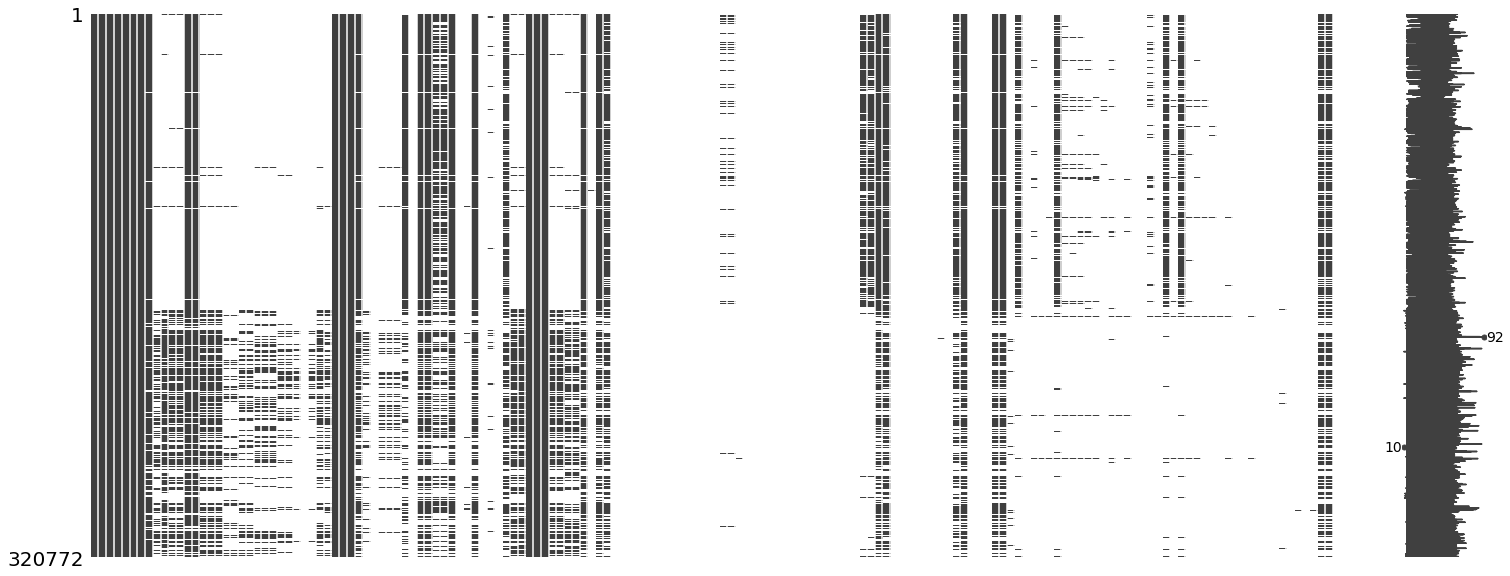

In [8]:
import missingno as msno

# Tracer une matrice de nullité
msno.matrix(data)

# Afficher le graphique
plt.show()


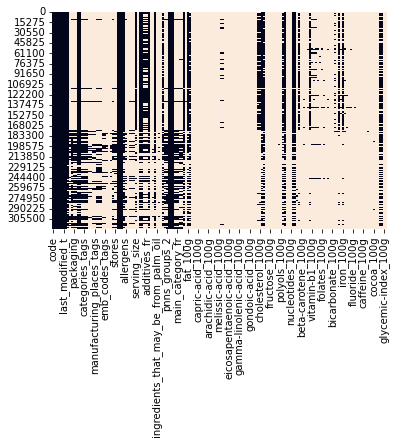

In [7]:
# Création d'une carte thermique des valeurs manquantes
sns.heatmap(data.isnull(), cbar=False)

plt.show()

In [24]:
#Séléction des variables contenant '100g'
cols_100g = [x for x in data.columns if '_100g' in x]


In [25]:
df = data.reindex(['nutrition_grade_fr','nutrition-score-fr_100g'] + cols_100g, axis=1)
df.head(5)

,nutrition_grade_fr,nutrition-score-fr_100g,energy_100g,energy-from-fat_100g,fat_100g,saturated-fat_100g,butyric-acid_100g,caproic-acid_100g,caprylic-acid_100g,capric-acid_100g,lauric-acid_100g,myristic-acid_100g,palmitic-acid_100g,stearic-acid_100g,arachidic-acid_100g,behenic-acid_100g,lignoceric-acid_100g,cerotic-acid_100g,montanic-acid_100g,melissic-acid_100g,monounsaturated-fat_100g,polyunsaturated-fat_100g,omega-3-fat_100g,alpha-linolenic-acid_100g,eicosapentaenoic-acid_100g,docosahexaenoic-acid_100g,omega-6-fat_100g,linoleic-acid_100g,arachidonic-acid_100g,gamma-linolenic-acid_100g,dihomo-gamma-linolenic-acid_100g,omega-9-fat_100g,oleic-acid_100g,elaidic-acid_100g,gondoic-acid_100g,mead-acid_100g,erucic-acid_100g,nervonic-acid_100g,trans-fat_100g,cholesterol_100g,carbohydrates_100g,sugars_100g,sucrose_100g,glucose_100g,fructose_100g,lactose_100g,maltose_100g,maltodextrins_100g,starch_100g,polyols_100g,fiber_100g,proteins_100g,casein_100g,serum-proteins_100g,nucleotides_100g,salt_100g,sodium_100g,alcohol_100g,vitamin-a_100g,beta-carotene_100g,vitamin-d_100g,vitamin-e_100g,vitamin-k_100g,vitamin-c_100g,vitamin-b1_100g,vitamin-b2_100g,vitamin-pp_100g,vitamin-b6_100g,vitamin-b9_100g,folates_100g,vitamin-b12_100g,biotin_100g,pantothenic-acid_100g,silica_100g,bicarbonate_100g,potassium_100g,chloride_100g,calcium_100g,phosphorus_100g,iron_100g,magnesium_100g,zinc_100g,copper_100g,manganese_100g,fluoride_100g,selenium_100g,chromium_100g,molybdenum_100g,iodine_100g,caffeine_100g,taurine_100g,ph_100g,fruits-vegetables-nuts_100g,collagen-meat-protein-ratio_100g,cocoa_100g,chlorophyl_100g,carbon-footprint_100g,nutrition-score-fr_100g,nutrition-score-uk_100g,glycemic-index_100g,water-hardness_100g
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,d,14.0,2243.0,NaN,28.57,28.57,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.018,64.29,14.29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.6,3.57,NaN,NaN,NaN,0.00000,0.000,NaN,0.0,NaN,NaN,NaN,NaN,0.0214,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,NaN,0.00129,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.0,14.0,NaN,NaN
2,b,0.0,1941.0,NaN,17.86,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.000,60.71,17.86,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.1,17.86,NaN,NaN,NaN,0.63500,0.250,NaN,0.0,NaN,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.071,NaN,0.00129,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN
3,d,12.0,2540.0,NaN,57.14,5.36,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.86,3.57,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.1,17.86,NaN,NaN,NaN,1.22428,0.482,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.143,NaN,0.00514,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.0,12.0,NaN,NaN
4,NaN,NaN,1552.0,NaN,1.43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,77.14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.7,8.57,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
#Séléction des variables contenants moins de 80% de nan
cols = []

for i in range(2, len(df.columns)):
    temp = int(df[df.columns[i]].isnull().sum() / df.shape[0] * 100)
    print(df.columns[i], ' - ', temp, '% de cellules vides')
    if temp < 80:
        cols.append(df.columns[i])

energy_100g  -  18 % de cellules vides
energy-from-fat_100g  -  99 % de cellules vides
fat_100g  -  23 % de cellules vides
saturated-fat_100g  -  28 % de cellules vides
butyric-acid_100g  -  100 % de cellules vides
caproic-acid_100g  -  100 % de cellules vides
caprylic-acid_100g  -  99 % de cellules vides
capric-acid_100g  -  99 % de cellules vides
lauric-acid_100g  -  99 % de cellules vides
myristic-acid_100g  -  99 % de cellules vides
palmitic-acid_100g  -  99 % de cellules vides
stearic-acid_100g  -  99 % de cellules vides
arachidic-acid_100g  -  99 % de cellules vides
behenic-acid_100g  -  99 % de cellules vides
lignoceric-acid_100g  -  100 % de cellules vides
cerotic-acid_100g  -  100 % de cellules vides
montanic-acid_100g  -  99 % de cellules vides
melissic-acid_100g  -  100 % de cellules vides
monounsaturated-fat_100g  -  92 % de cellules vides
polyunsaturated-fat_100g  -  92 % de cellules vides
omega-3-fat_100g  -  99 % de cellules vides
alpha-linolenic-acid_100g  -  99 % de ce

TypeError: cannot convert the series to <class 'int'>

In [27]:
df = df.loc[:, cols]


## Nettoyage avec iterative imputer 

In [14]:
imputer = IterativeImputer()

In [15]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Sélectionnez les colonnes avec des valeurs manquantes à imputer
cols_with_missing_values = df.columns

# Créez une instance de l'imputeur
imputer = IterativeImputer()

# Appliquez l'imputation sur les colonnes sélectionnées
data[cols_with_missing_values] = imputer.fit_transform(df[cols_with_missing_values])

In [16]:
data[cols_with_missing_values].head(50)

,energy_100g,fat_100g,saturated-fat_100g,trans-fat_100g,cholesterol_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,vitamin-a_100g,vitamin-c_100g,calcium_100g,iron_100g
0,1143.576808,12.842031,4.730213,0.070613,0.021256,32.038004,15.497292,2.302617,7.079712,2.028624,0.798669,0.000180,0.016334,0.074800,0.003418
1,2243.000000,28.570000,28.570000,0.000000,0.018000,64.290000,14.290000,3.600000,3.570000,0.000000,0.000000,0.000000,0.021400,0.000000,0.001290
2,1941.000000,17.860000,0.000000,0.000000,0.000000,60.710000,17.860000,7.100000,17.860000,0.635000,0.250000,0.000000,0.000000,0.071000,0.001290
3,2540.000000,57.140000,5.360000,0.151845,0.024790,17.860000,3.570000,7.100000,17.860000,1.224280,0.482000,-0.000299,-0.055333,0.143000,0.005140
4,1552.000000,1.430000,1.866170,0.055491,0.002981,77.140000,35.395439,5.700000,8.570000,2.028946,0.798797,0.010174,0.241291,0.139372,0.130486
5,1933.000000,18.270000,1.920000,0.087864,0.006012,63.460000,11.540000,7.700000,13.460000,2.028931,0.798792,0.002191,0.036489,0.038000,0.003460
6,1490.000000,11.424363,4.805142,0.066301,-0.005037,80.000000,34.666641,12.135695,8.890000,2.029037,0.798834,0.017271,0.002700,0.044000,0.213468
7,1833.000000,18.750000,4.690000,0.074376,0.008502,57.810000,15.620000,9.400000,14.060000,0.139700,0.055000,0.006326,0.097847,0.062000,0.004220
8,2406.000000,37.500000,22.500000,0.122140,0.034824,55.000000,42.500000,7.500000,5.000000,2.029169,0.798879,0.010694,0.168725,0.050000,0.011250
9,3586.000000,100.000000,7.140000,0.240317,-0.012687,10.352769,-18.066170,25.218990,16.393381,2.029185,0.798901,0.054984,1.093299,1.810542,0.652557


In [18]:
data[cols_with_missing_values] = data[cols_with_missing_values].abs()


In [20]:
data[cols_with_missing_values].describe()

,energy_100g,fat_100g,saturated-fat_100g,trans-fat_100g,cholesterol_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,vitamin-a_100g,vitamin-c_100g,calcium_100g,iron_100g
count,3.207720e+05,320772.000000,320772.000000,320772.000000,320772.000000,320772.000000,320772.000000,320772.000000,320772.000000,320772.000000,320772.000000,320772.000000,320772.000000,320772.000000,320772.000000
mean,1.143604e+03,12.885564,4.761630,0.071406,0.022892,32.057043,15.681979,3.371907,7.091615,2.028624,0.798669,0.008615,0.170795,0.257378,0.104420
std,5.822657e+03,17.037055,7.127508,1.030964,0.338413,30.408897,19.725445,19.986364,7.656275,114.479784,45.070780,0.237150,4.456563,11.113943,2.897759
min,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.980000e+02,0.900000,0.198313,0.000000,0.000000,9.560000,2.410000,0.500000,1.600000,0.120000,0.047244,0.000020,0.000000,0.035000,0.001290
50%,1.143577e+03,10.770000,3.330000,0.044349,0.017000,32.038004,10.710000,2.302617,6.900000,0.952500,0.375000,0.000180,0.016334,0.074800,0.003418
75%,1.569000e+03,16.000000,5.000000,0.070613,0.022291,50.000000,16.670000,4.031887,8.330000,2.028624,0.798669,0.010153,0.196076,0.226501,0.123669
max,3.251373e+06,3342.204212,964.930711,369.000000,133.377284,8613.813184,3520.000000,6626.919298,800.000000,64312.800000,25320.000000,121.262346,2263.382388,6126.511328,1488.533398


In [83]:
df.at[3, 'trans-fat_100g'] = 0.03587872959153666

In [73]:
df.head(50)

,nutriscore_score,nova_group,nutriscore_grade,energy-kcal_100g,energy_100g,fat_100g,saturated-fat_100g,trans-fat_100g,cholesterol_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,vitamin-a_100g,vitamin-c_100g,calcium_100g,iron_100g,fruits-vegetables-nuts-estimate-from-ingredients_100g,nutrition-score-fr_100g
0,14.0,4.0,d,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.0,0.0,0.000,0.0000,0.0,0.0,0.0,0.0,0.0,14.0
1,14.0,4.0,d,165.0,690.0,2.0,2.00,0.0,0.0,65.0,12.60,3.0,1.5,0.000,0.0000,0.0,0.0,0.0,0.0,0.0,14.0
2,14.0,4.0,d,0.0,0.0,1.4,0.90,0.0,0.0,9.8,9.80,0.0,2.7,0.100,0.0400,0.0,0.0,0.0,0.0,0.0,14.0
3,-5.0,4.0,a,57.0,238.0,0.2,0.10,0.0,0.0,3.9,3.90,0.0,10.0,0.090,0.0360,0.0,0.0,0.0,0.0,0.0,-5.0
4,14.0,4.0,d,375.0,1569.0,7.0,3.08,0.0,0.0,70.1,15.00,0.0,7.8,1.400,0.5600,0.0,0.0,0.0,0.0,0.0,14.0
5,14.0,4.0,d,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.0,0.0,0.000,0.0000,0.0,0.0,0.0,0.0,0.0,14.0
6,14.0,4.0,d,163.9,685.8,1.9,1.00,0.0,0.0,0.0,0.00,0.0,15.3,1.100,0.4400,0.0,0.0,0.0,0.0,0.0,14.0
7,14.0,4.0,d,194.0,812.0,11.0,3.90,0.0,0.0,5.7,0.05,0.0,18.0,0.000,0.0000,0.0,0.0,0.0,0.0,0.0,14.0
8,14.0,4.0,d,874.9,3661.0,15.1,6.10,0.0,0.0,2.6,1.00,0.0,15.7,2.100,0.8400,0.0,0.0,0.0,0.0,0.0,14.0
9,14.0,4.0,d,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.0,0.0,0.000,0.0000,0.0,0.0,0.0,0.0,0.0,14.0


## Nettoyage avec l'algorithme des KNNs

In [28]:
# Split Train(70%) & Test(30%) to keep an "unknown" dataset from our model ## 80-20 to test* 
from sklearn.model_selection import train_test_split


train, test = train_test_split(df, test_size=0.3)

train.shape[0]

224540

C:\Users\asus\.InstallAnywhere\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


Text(0.5, 1.0, 'Distribution de sugars_100g avant cleaning')

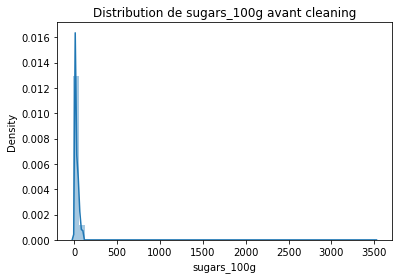

In [29]:
sns.distplot(df['sugars_100g'])
plt.title('Distribution de sugars_100g avant cleaning')

In [30]:
#On remplace les valeurs <0 et >100 par NAN
changes = 0
numeric_cols = train.columns.tolist()  

for _, row in train.iterrows():
    for col in numeric_cols:
        if not pd.isna(row[col]):
            if (row[col] < 0) or (row[col] > 100):
                row[col] = np.nan
                changes += 1

changes

170222

In [31]:
train['sugars_100g'].describe()

count    171447.000000
mean         16.000241
std          21.187898
min           0.000000
25%           1.300000
50%           5.700000
75%          24.000000
max         100.000000
Name: sugars_100g, dtype: float64

C:\Users\asus\.InstallAnywhere\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


Text(0.5, 1.0, 'Distribution de sugars_100g après cleaning')

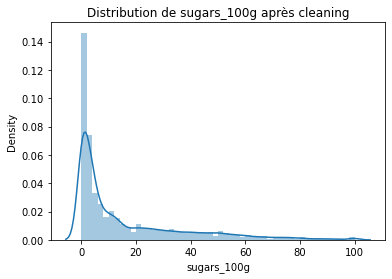

In [32]:
sns.distplot(train['sugars_100g'])
plt.title('Distribution de sugars_100g après cleaning')

In [33]:
#On applique notre algorithme au reste des variables 
for i in range(2,len(train.columns)):
    print(cols[i],':\n',train[cols[i]].describe(),'\n-------------\n\n')

saturated-fat_100g :
 count    160669.000000
mean          5.132595
std           7.925539
min           0.000000
25%           0.000000
50%           1.790000
75%           7.140000
max         100.000000
Name: saturated-fat_100g, dtype: float64 
-------------


trans-fat_100g :
 count    100279.000000
mean          0.070249
std           1.013989
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         100.000000
Name: trans-fat_100g, dtype: float64 
-------------


cholesterol_100g :
 count    100812.000000
mean          0.020187
std           0.379316
min           0.000000
25%           0.000000
50%           0.000000
75%           0.020000
max          95.238000
Name: cholesterol_100g, dtype: float64 
-------------


carbohydrates_100g :
 count    170308.000000
mean         32.051003
std          29.124291
min           0.000000
25%           6.000000
50%          20.625000
75%          58.270000
max         100.000000
Name: carbohyd

## Valeurs aberrantes pour la feature iron_100g ( méthode percentile)


In [34]:
train['iron_100g'].quantile([0.25,0.5,0.75,0.995])


0.250    0.00000
0.500    0.00101
0.750    0.00240
0.995    0.02893
Name: iron_100g, dtype: float64

Text(0.5, 1.0, 'Boite à moustache pour iron_100g avant cleaning')

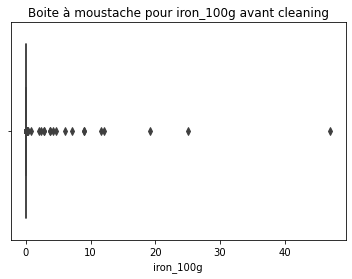

In [36]:
ax = sns.boxplot(x=train["iron_100g"])
plt.title('Boite à moustache pour iron_100g avant cleaning')

In [37]:
train['iron_100g']= train['iron_100g'].where(train['iron_100g']<train['iron_100g'].quantile(0.995))


Text(0.5, 1.0, 'Boite à moustache iron après cleaning')

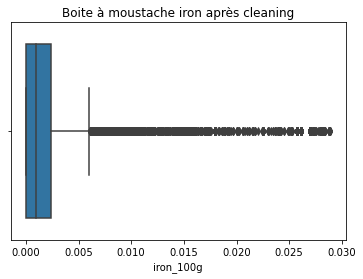

In [38]:
ax = sns.boxplot(x=train["iron_100g"])
plt.title('Boite à moustache iron après cleaning')

In [152]:
train['saturated-fat_100g'].quantile([0.25,0.5,0.75,0.995])


0.250     0.00
0.500     1.79
0.750     7.14
0.995    50.00
Name: saturated-fat_100g, dtype: float64

Text(0.5, 1.0, 'Boite à moustache fat_100g avant cleaning')

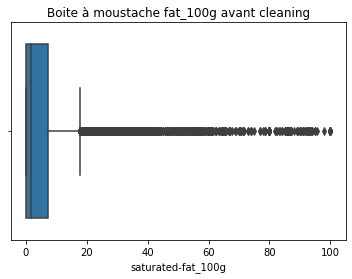

In [153]:
ax = sns.boxplot(x=train["saturated-fat_100g"])
plt.title('Boite à moustache fat_100g avant cleaning')# boxplot name to change

In [154]:
train['saturated-fat_100g']= train['saturated-fat_100g'].where(train['saturated-fat_100g']<train['saturated-fat_100g'].quantile(0.995))


Text(0.5, 1.0, 'Boite à moustache fat après cleaning')

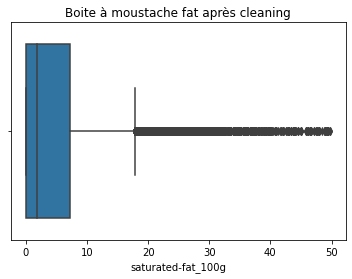

In [155]:
ax = sns.boxplot(x=train["saturated-fat_100g"])
plt.title('Boite à moustache fat après cleaning')

## Supprimer la ligne avec trop de NaN (ici> 2 NaN)


In [39]:
train['missing_values'] = train.isnull().sum(axis=1)


In [40]:
train['missing_values'].describe()

count    224540.000000
mean          6.281651
std           5.214160
min           0.000000
25%           1.000000
50%           7.000000
75%           9.000000
max          15.000000
Name: missing_values, dtype: float64

In [41]:
train=train[train['missing_values']<3]
train=train.drop(columns=['missing_values'])

In [42]:
train.head(50)


,energy_100g,fat_100g,saturated-fat_100g,trans-fat_100g,cholesterol_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,vitamin-a_100g,vitamin-c_100g,calcium_100g,iron_100g
135506,NaN,4.65,2.91,0.0,0.023,26.74,24.42,0.0,4.65,0.26670,0.105,0.000070,0.0070,0.116,0.00000
83156,NaN,0.00,0.00,0.0,0.000,3.33,3.33,0.0,0.00,2.79400,1.100,0.000000,0.0400,0.067,0.00900
125906,NaN,36.67,5.00,0.0,0.000,10.00,6.67,0.0,0.00,2.03200,0.800,0.000000,0.0000,0.000,0.00000
41590,NaN,12.50,1.56,0.0,0.016,9.38,3.12,0.0,3.12,1.50876,0.594,0.000469,0.0038,0.062,0.00000
24837,NaN,1.18,0.00,0.0,0.018,43.53,1.18,3.5,7.06,0.95504,0.376,0.000000,0.0212,0.024,0.00085
165286,NaN,0.00,0.00,0.0,0.000,100.00,0.00,0.0,0.00,31.75000,12.500,0.003000,0.0000,0.000,0.00000
109329,NaN,5.38,0.77,0.0,0.000,69.23,38.46,1.5,12.31,0.78232,0.308,0.000000,0.0646,0.385,0.00692
20688,NaN,0.00,0.00,0.0,0.000,7.20,1.60,1.6,0.80,0.62992,0.248,0.000840,0.0029,0.032,0.00029
92245,NaN,2.94,0.00,0.0,0.029,72.55,1.96,3.9,13.73,0.02540,0.010,0.000000,0.0000,0.000,0.00353
92578,NaN,45.00,5.00,0.0,0.000,20.00,2.50,10.0,20.00,1.71450,0.675,0.000150,0.0030,0.100,0.00450


## Scaler + KNN ( Utilisez KNN Imputer pour remplacer les valeurs NaN restantes dans le dataset)


In [43]:
scaler = StandardScaler().fit(train)
scaled_train= scaler.transform(train)

In [207]:
## Enregistrer l'objet scaler dans un fichier

with open('scaler_1.pickle', 'wb') as file:
    pickle.dump(scaler, file)

In [44]:
# Créer une instance de KNNImputer avec le nombre de voisins spécifié
imputer = KNNImputer(n_neighbors=3)
# Effectuer l'imputation sur les données d'entraînement
knn_train = imputer.fit_transform(scaled_train)

In [45]:
filled_data = scaler.inverse_transform(knn_train)

In [46]:
train_filled1 = pd.DataFrame(filled_data, columns=train.columns, index=train.index)


In [47]:
train_filled1['nan']= len(train_filled1.columns)-train_filled1.count(axis=1)

train_filled1.describe()

,energy_100g,fat_100g,saturated-fat_100g,trans-fat_100g,cholesterol_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,vitamin-a_100g,vitamin-c_100g,calcium_100g,iron_100g,nan
count,91614.000000,91614.000000,91614.000000,91614.000000,91614.000000,91614.000000,9.161400e+04,91614.000000,91614.000000,91614.000000,91614.000000,9.161400e+04,9.161400e+04,91614.000000,9.161400e+04,91614.0
mean,53.122482,13.340076,4.696679,0.065826,0.019358,35.314417,1.531182e+01,2.859546,7.987759,1.319475,0.520760,1.352121e-04,6.180484e-03,0.091698,1.679632e-03,0.0
std,26.412522,15.503660,6.845755,0.990149,0.395794,28.209161,1.951503e+01,4.483947,8.243044,3.960328,1.602786,6.223302e-04,1.219507e-01,0.231336,2.732095e-03,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.776357e-15,0.000000,0.000000,0.000000,0.000000,-2.710505e-20,-8.673617e-19,0.000000,-2.168404e-19,0.0
25%,33.333333,0.780000,0.000000,0.000000,0.000000,8.790000,1.590000e+00,0.000000,2.350000,0.142240,0.056000,0.000000e+00,0.000000e+00,0.000000,-2.168404e-19,0.0
50%,57.000000,7.610000,1.760000,0.000000,0.000000,28.240000,5.710000e+00,1.500000,5.630000,0.741680,0.292000,0.000000e+00,0.000000e+00,0.034000,9.600000e-04,0.0
75%,71.000000,21.430000,7.140000,0.000000,0.020000,60.710000,2.410000e+01,3.600000,11.000000,1.450340,0.571000,9.990000e-05,2.100000e-03,0.100000,2.400000e-03,0.0
max,100.000000,100.000000,100.000000,100.000000,95.238000,100.000000,1.000000e+02,100.000000,100.000000,99.905820,92.500000,7.600000e-02,3.571430e+01,35.714000,2.890000e-02,0.0


In [49]:
train_filled=train_filled1.abs()

In [50]:
train_filled.head(15)


,energy_100g,fat_100g,saturated-fat_100g,trans-fat_100g,cholesterol_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,vitamin-a_100g,vitamin-c_100g,calcium_100g,iron_100g,nan
135506,33.333333,4.65,2.91,0.0,0.023,26.74,2.442000e+01,0.0,4.65,0.26670,0.105,0.000070,0.0070,0.116,2.168404e-19,0
83156,54.333333,0.00,0.00,0.0,0.000,3.33,3.330000e+00,0.0,0.00,2.79400,1.100,0.000000,0.0400,0.067,9.000000e-03,0
125906,0.000000,36.67,5.00,0.0,0.000,10.00,6.670000e+00,0.0,0.00,2.03200,0.800,0.000000,0.0000,0.000,2.168404e-19,0
41590,75.000000,12.50,1.56,0.0,0.016,9.38,3.120000e+00,0.0,3.12,1.50876,0.594,0.000469,0.0038,0.062,2.168404e-19,0
24837,29.333333,1.18,0.00,0.0,0.018,43.53,1.180000e+00,3.5,7.06,0.95504,0.376,0.000000,0.0212,0.024,8.500000e-04,0
165286,0.000000,0.00,0.00,0.0,0.000,100.00,1.776357e-15,0.0,0.00,31.75000,12.500,0.003000,0.0000,0.000,2.168404e-19,0
109329,78.000000,5.38,0.77,0.0,0.000,69.23,3.846000e+01,1.5,12.31,0.78232,0.308,0.000000,0.0646,0.385,6.920000e-03,0
20688,91.666667,0.00,0.00,0.0,0.000,7.20,1.600000e+00,1.6,0.80,0.62992,0.248,0.000840,0.0029,0.032,2.900000e-04,0
92245,44.666667,2.94,0.00,0.0,0.029,72.55,1.960000e+00,3.9,13.73,0.02540,0.010,0.000000,0.0000,0.000,3.530000e-03,0
92578,33.333333,45.00,5.00,0.0,0.000,20.00,2.500000e+00,10.0,20.00,1.71450,0.675,0.000150,0.0030,0.100,4.500000e-03,0


In [51]:
train_filled.to_csv('train_filled.csv')

## Drop Sum > 100g (Supprimer les lignes avec une somme supérieure à 100 g « macro-nourriture » )


In [52]:
filled= pd.read_csv("train_filled.csv")


In [53]:
filled.head()

,Unnamed: 0,energy_100g,fat_100g,saturated-fat_100g,trans-fat_100g,cholesterol_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,vitamin-a_100g,vitamin-c_100g,calcium_100g,iron_100g,nan
0,135506,33.333333,4.65,2.91,0.0,0.023,26.74,24.42,0.0,4.65,0.26670,0.105,0.000070,0.0070,0.116,2.168404e-19,0
1,83156,54.333333,0.00,0.00,0.0,0.000,3.33,3.33,0.0,0.00,2.79400,1.100,0.000000,0.0400,0.067,9.000000e-03,0
2,125906,0.000000,36.67,5.00,0.0,0.000,10.00,6.67,0.0,0.00,2.03200,0.800,0.000000,0.0000,0.000,2.168404e-19,0
3,41590,75.000000,12.50,1.56,0.0,0.016,9.38,3.12,0.0,3.12,1.50876,0.594,0.000469,0.0038,0.062,2.168404e-19,0
4,24837,29.333333,1.18,0.00,0.0,0.018,43.53,1.18,3.5,7.06,0.95504,0.376,0.000000,0.0212,0.024,8.500000e-04,0


In [54]:
filled['sum_100g']=filled['fat_100g']+filled['carbohydrates_100g']+filled['fiber_100g']+filled['proteins_100g']+filled['salt_100g']
filled.head()

,Unnamed: 0,energy_100g,fat_100g,saturated-fat_100g,trans-fat_100g,cholesterol_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,vitamin-a_100g,vitamin-c_100g,calcium_100g,iron_100g,nan,sum_100g
0,135506,33.333333,4.65,2.91,0.0,0.023,26.74,24.42,0.0,4.65,0.26670,0.105,0.000070,0.0070,0.116,2.168404e-19,0,36.30670
1,83156,54.333333,0.00,0.00,0.0,0.000,3.33,3.33,0.0,0.00,2.79400,1.100,0.000000,0.0400,0.067,9.000000e-03,0,6.12400
2,125906,0.000000,36.67,5.00,0.0,0.000,10.00,6.67,0.0,0.00,2.03200,0.800,0.000000,0.0000,0.000,2.168404e-19,0,48.70200
3,41590,75.000000,12.50,1.56,0.0,0.016,9.38,3.12,0.0,3.12,1.50876,0.594,0.000469,0.0038,0.062,2.168404e-19,0,26.50876
4,24837,29.333333,1.18,0.00,0.0,0.018,43.53,1.18,3.5,7.06,0.95504,0.376,0.000000,0.0212,0.024,8.500000e-04,0,56.22504


In [55]:
filled['sum_100g'].describe()


count    91614.000000
mean        60.821272
std         34.729509
min          0.000000
25%         27.041480
50%         62.251780
75%         95.024180
max        239.690000
Name: sum_100g, dtype: float64

In [57]:
filled= filled.loc[filled['sum_100g']<=100]


C:\Users\asus\.InstallAnywhere\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


Text(0.5, 1.0, 'Distribution Sucres_100g après nettoyage multivarié')

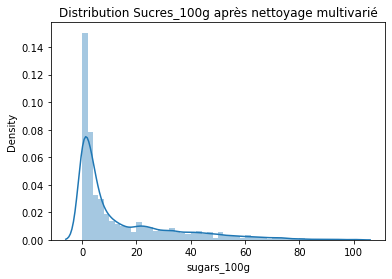

In [58]:
sns.distplot(filled['sugars_100g'])
plt.title('Distribution Sucres_100g après nettoyage multivarié')

In [59]:
filled= filled.drop(columns='sum_100g')

In [61]:
filled= filled.drop(columns='Unnamed: 0')

In [62]:
filled= filled.drop(columns='nan')

In [63]:
filled.head(5)


,energy_100g,fat_100g,saturated-fat_100g,trans-fat_100g,cholesterol_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,vitamin-a_100g,vitamin-c_100g,calcium_100g,iron_100g
0,33.333333,4.65,2.91,0.0,0.023,26.74,24.42,0.0,4.65,0.26670,0.105,0.000070,0.0070,0.116,2.168404e-19
1,54.333333,0.00,0.00,0.0,0.000,3.33,3.33,0.0,0.00,2.79400,1.100,0.000000,0.0400,0.067,9.000000e-03
2,0.000000,36.67,5.00,0.0,0.000,10.00,6.67,0.0,0.00,2.03200,0.800,0.000000,0.0000,0.000,2.168404e-19
3,75.000000,12.50,1.56,0.0,0.016,9.38,3.12,0.0,3.12,1.50876,0.594,0.000469,0.0038,0.062,2.168404e-19
4,29.333333,1.18,0.00,0.0,0.018,43.53,1.18,3.5,7.06,0.95504,0.376,0.000000,0.0212,0.024,8.500000e-04


## KDTree est utilisé pour repérer les valeurs aberrantes multivariées


In [64]:
test_kdtree=filled.copy()


In [66]:
scaler = StandardScaler().fit(test_kdtree)
scaled_data= scaler.transform(test_kdtree)
scaled_tree = spatial.KDTree(scaled_data)
neighbours_scaled = scaled_tree.query(scaled_data,k=3)
dist_scaled = pd.DataFrame(neighbours_scaled[0])


In [67]:
dist_scaled = dist_scaled.drop(columns=0)
dist_scaled['mean']=dist_scaled.mean(axis=1)


In [68]:
dist_scaled['mean'].describe()

count    78274.000000
mean         0.276039
std          1.218309
min          0.000000
25%          0.002651
50%          0.173906
75%          0.375064
max        256.481833
Name: mean, dtype: float64

C:\Users\asus\.InstallAnywhere\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


Text(0.5, 1.0, 'Boxplot de la distance moyenne aux 5 KNN avant gestion des outliers')

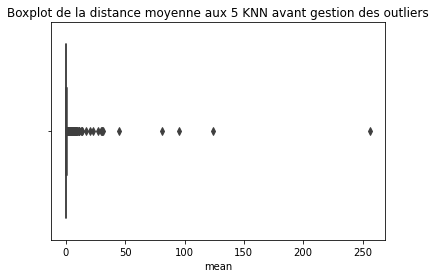

In [69]:
sns.boxplot(dist_scaled['mean'])
plt.title('Boxplot de la distance moyenne aux 5 KNN avant gestion des outliers')

In [70]:
dist_scaled['mean'].quantile(0.99)


1.6594232545074827

In [71]:
dist_scaled.shape[0]-dist_scaled[dist_scaled['mean']<dist_scaled['mean'].quantile(0.99)].count()


1       783
2       783
mean    783
dtype: int64

In [73]:
filled['mean']=dist_scaled['mean'].values
filled.head()

,energy_100g,fat_100g,saturated-fat_100g,trans-fat_100g,cholesterol_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,vitamin-a_100g,vitamin-c_100g,calcium_100g,iron_100g,mean
0,33.333333,4.65,2.91,0.0,0.023,26.74,24.42,0.0,4.65,0.26670,0.105,0.000070,0.0070,0.116,2.168404e-19,0.122798
1,54.333333,0.00,0.00,0.0,0.000,3.33,3.33,0.0,0.00,2.79400,1.100,0.000000,0.0400,0.067,9.000000e-03,1.211746
2,0.000000,36.67,5.00,0.0,0.000,10.00,6.67,0.0,0.00,2.03200,0.800,0.000000,0.0000,0.000,2.168404e-19,0.152554
3,75.000000,12.50,1.56,0.0,0.016,9.38,3.12,0.0,3.12,1.50876,0.594,0.000469,0.0038,0.062,2.168404e-19,0.421730
4,29.333333,1.18,0.00,0.0,0.018,43.53,1.18,3.5,7.06,0.95504,0.376,0.000000,0.0212,0.024,8.500000e-04,0.165777


C:\Users\asus\.InstallAnywhere\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


Text(0.5, 1.0, 'Boxplot de la distance moyenne aux 5 KNN après gestion des outliers')

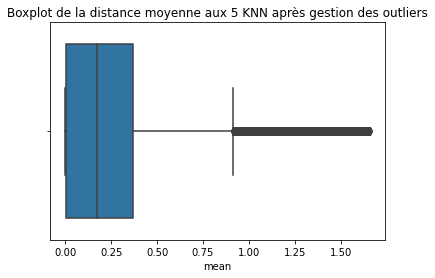

In [74]:
sns.boxplot(dist_scaled['mean'][dist_scaled['mean']<dist_scaled['mean'].quantile(0.99)])
plt.title('Boxplot de la distance moyenne aux 3 KNN après gestion des outliers')

In [75]:
dist_scaled['mean'][dist_scaled['mean']<dist_scaled['mean'].quantile(0.99)]


0        1.227978e-01
1        1.211746e+00
2        1.525541e-01
3        4.217300e-01
4        1.657774e-01
5        1.678390e-01
6        2.525988e-01
7        0.000000e+00
8        4.911692e-01
9        3.686688e-01
10       0.000000e+00
11       6.964019e-02
12       3.305218e-01
13       9.712243e-02
14       9.229420e-02
15       0.000000e+00
16       8.094301e-02
17       5.610719e-01
18       3.388702e-01
19       3.125726e-01
21       1.251270e-01
22       1.333357e-01
23       5.519942e-01
24       1.633848e-01
25       3.114179e-02
26       6.329633e-01
27       3.305917e-01
28       3.957175e-01
29       3.603600e-01
30       1.302460e+00
31       0.000000e+00
32       4.496731e-01
33       3.349879e-01
34       8.278785e-02
35       0.000000e+00
36       3.711790e-01
37       1.209321e-01
38       9.364389e-02
39       1.004354e-01
40       2.915635e-02
41       6.412422e-02
42       1.999077e-02
43       0.000000e+00
44       1.647832e-01
45       3.706437e-02
46       1

In [77]:
filled= filled.loc[filled['mean']<filled['mean'].quantile(0.99)]
filled.head()

,energy_100g,fat_100g,saturated-fat_100g,trans-fat_100g,cholesterol_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,vitamin-a_100g,vitamin-c_100g,calcium_100g,iron_100g,mean
0,33.333333,4.65,2.91,0.0,0.023,26.74,24.42,0.0,4.65,0.26670,0.105,0.000070,0.0070,0.116,2.168404e-19,0.122798
1,54.333333,0.00,0.00,0.0,0.000,3.33,3.33,0.0,0.00,2.79400,1.100,0.000000,0.0400,0.067,9.000000e-03,1.211746
2,0.000000,36.67,5.00,0.0,0.000,10.00,6.67,0.0,0.00,2.03200,0.800,0.000000,0.0000,0.000,2.168404e-19,0.152554
3,75.000000,12.50,1.56,0.0,0.016,9.38,3.12,0.0,3.12,1.50876,0.594,0.000469,0.0038,0.062,2.168404e-19,0.421730
4,29.333333,1.18,0.00,0.0,0.018,43.53,1.18,3.5,7.06,0.95504,0.376,0.000000,0.0212,0.024,8.500000e-04,0.165777


In [207]:
filled.describe()

,nutriscore_score,energy_100g,fat_100g,saturated-fat_100g,trans-fat_100g,cholesterol_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,vitamin-a_100g,vitamin-c_100g,calcium_100g,iron_100g,fruits-vegetables-nuts-estimate-from-ingredients_100g,mean
count,63595.000000,63595.000000,63595.000000,63595.000000,63595.000000,63595.000000,63595.000000,63595.000000,63595.000000,63595.000000,63595.000000,63595.000000,63595.000000,63595.000000,63595.000000,63595.000000,63595.000000,63595.000000
mean,10.757128,1024.930829,10.172502,3.880243,0.021670,0.018612,31.710533,13.818599,1.683853,6.961611,1.199011,0.479605,0.000122,0.005203,0.088120,0.001397,4.792538,0.234476
std,6.971124,668.390304,12.704572,5.821086,0.262678,0.033756,27.968472,18.617756,2.251056,7.451184,3.310535,1.324213,0.000782,0.020064,0.173648,0.002791,16.119189,0.226155
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.000000,377.000000,0.000000,0.000000,0.000000,0.000000,7.080000,1.570000,0.000000,1.640000,0.152500,0.061000,0.000000,0.000000,0.000000,0.000000,0.000000,0.061310
50%,10.000000,1033.000000,4.650000,1.160000,0.000000,0.000000,21.000000,4.840000,0.900000,4.600000,0.760000,0.304000,0.000005,0.000000,0.031000,0.000640,0.000000,0.185812
75%,16.000000,1569.000000,16.670000,6.060000,0.000000,0.025000,56.360000,20.630000,2.600000,9.920000,1.463407,0.585363,0.000106,0.002800,0.100000,0.001820,0.000000,0.334747
max,38.000000,3289.000000,100.000000,92.860000,10.710000,0.553000,100.000000,100.000000,26.190476,71.430000,98.332500,39.333000,0.150000,0.470000,2.500000,0.090000,100.000000,1.431788


In [148]:
filled.to_csv('openfoodfacts_clean.csv')


In [208]:
test.to_csv('test.csv')